In [18]:
# REPLACE THESE FIRST
oasis_path = r"C:\Users\catra\Downloads\oasis\Images"

In [19]:
import pandas as pd

df = pd.read_csv('OASIS.csv')
print(len(df))
df.head()

900


,Unnamed: 0,Theme,Category,Source,Valence_mean,Valence_SD,Valence_N,Arousal_mean,Arousal_SD,Arousal_N
0,I1,Acorns 1,Object,Pixabay,4.686275,0.954203,102,2.346535,1.602720,101
1,I2,Acorns 2,Object,Pixabay,4.519608,0.841150,102,2.227723,1.399151,101
2,I3,Acorns 3,Object,Pixabay,4.754902,0.958921,102,2.306931,1.514877,101
3,I4,Alcohol 1,Object,Pixabay,4.685185,1.189111,108,2.865385,1.695555,104
4,I5,Alcohol 2,Object,Pixabay,4.250000,1.136686,108,3.000000,1.700942,104


In [20]:
print(df.Category.unique())

['Object' 'Person' 'Animal' 'Scene']


In [21]:
print(df.Valence_N.unique())

[102 108 101]


In [22]:
print(df.Arousal_N.unique())

[101 104 103 102 100]


In [23]:
df = df[df['Category'] !='Animal']
df = df[df['Category'] !='Person']

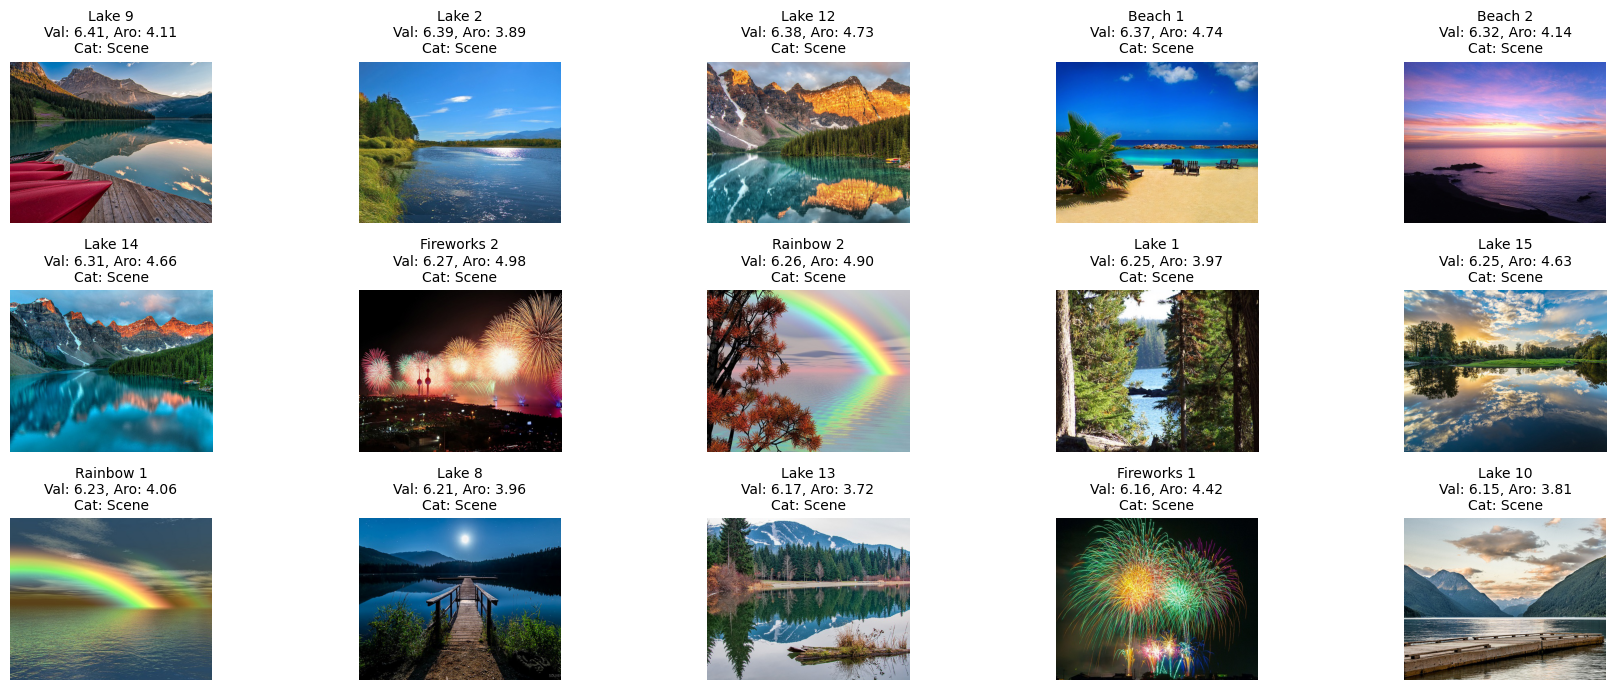

In [24]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import shutil

# df_filtered = df[df['Valence_mean'] >= 7]
top_subset = df.nlargest(15, ['Valence_mean', 'Arousal_mean']) 

fig, axes = plt.subplots(3, 5, figsize=(18, 7))
axes = axes.ravel()

os.makedirs('positive', exist_ok=True)
os.makedirs('negative', exist_ok=True)

for i, (_, row) in enumerate(top_subset.head(15).iterrows()):
    theme = row['Theme']
    category = row['Category']
    valence = row['Valence_mean']
    arousal = row['Arousal_mean']

    for ext in ['.jpg', '.png', '.jpeg']:
        path = os.path.join(oasis_path, theme + ext)
        if os.path.exists(path):
            img_path = path
            break
    else:
        continue  

    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(
        f"{theme}\nVal: {valence:.2f}, Aro: {arousal:.2f}\nCat: {category}",
        fontsize=10
    )

    filename = os.path.basename(img_path)
    shutil.copy(img_path, os.path.join("positive", filename))

plt.tight_layout()
plt.show()

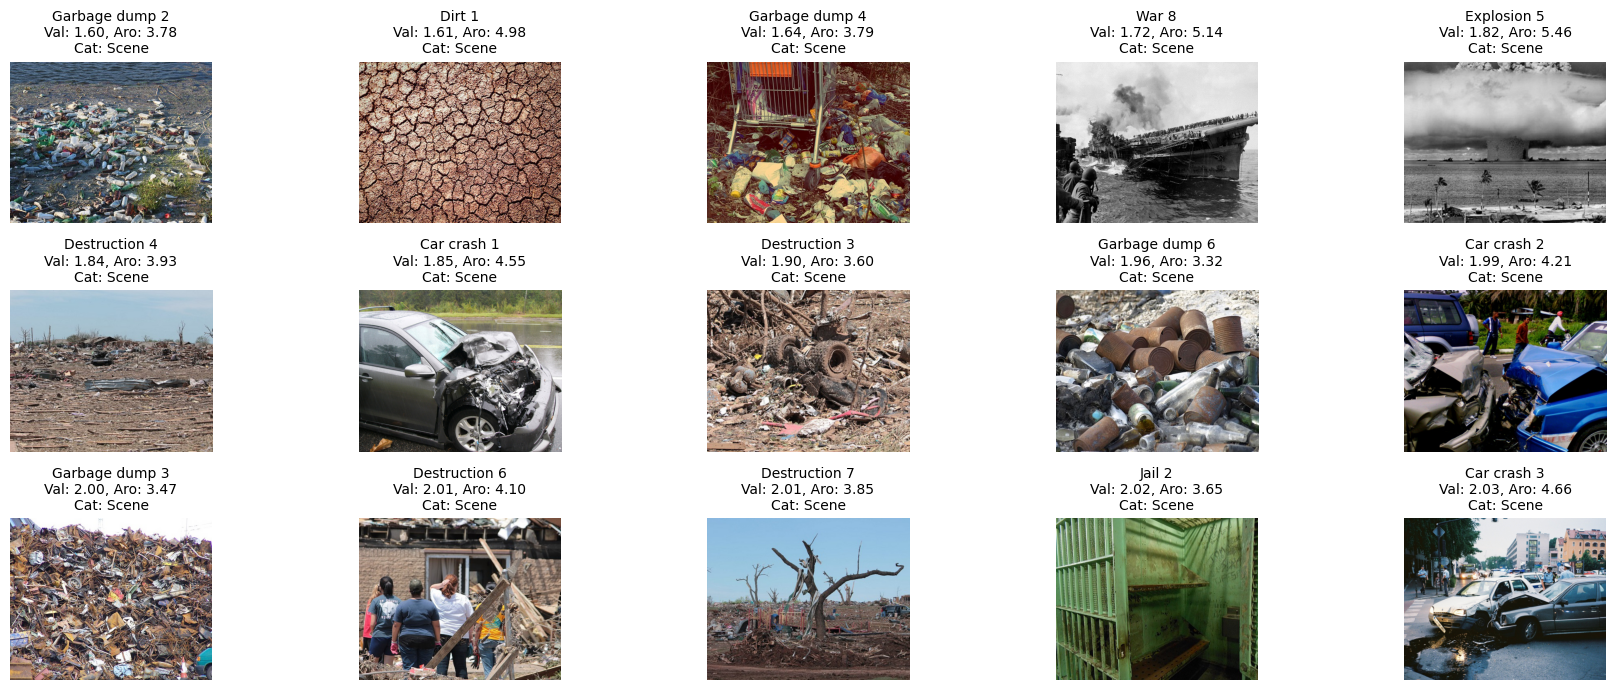

In [25]:
df_filtered = df[(df['Category'] == 'Scene')]
df_filtered = df_filtered[~df_filtered['Theme'].str.startswith('Fire')]
# bottom_subset = df_filtered.nsmallest(15, ['Valence_mean', 'Arousal_mean']) 

bottom_subset = (
    df_filtered
    .sort_values(by=['Valence_mean', 'Arousal_mean'], ascending=[True, False])
    .head(15)
)

fig, axes = plt.subplots(3, 5, figsize=(18, 7))
axes = axes.ravel()

for i, (_, row) in enumerate(bottom_subset.head(15).iterrows()):
    theme = row['Theme']
    category = row['Category']
    valence = row['Valence_mean']
    arousal = row['Arousal_mean']

    for ext in ['.jpg', '.png', '.jpeg']:
        path = os.path.join(oasis_path, theme + ext)
        if os.path.exists(path):
            img_path = path
            break
    else:
        continue  

    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(
        f"{theme}\nVal: {valence:.2f}, Aro: {arousal:.2f}\nCat: {category}",
        fontsize=10
    )

    filename = os.path.basename(img_path)
    shutil.copy(img_path, os.path.join("negative", filename))

plt.tight_layout()
plt.show()

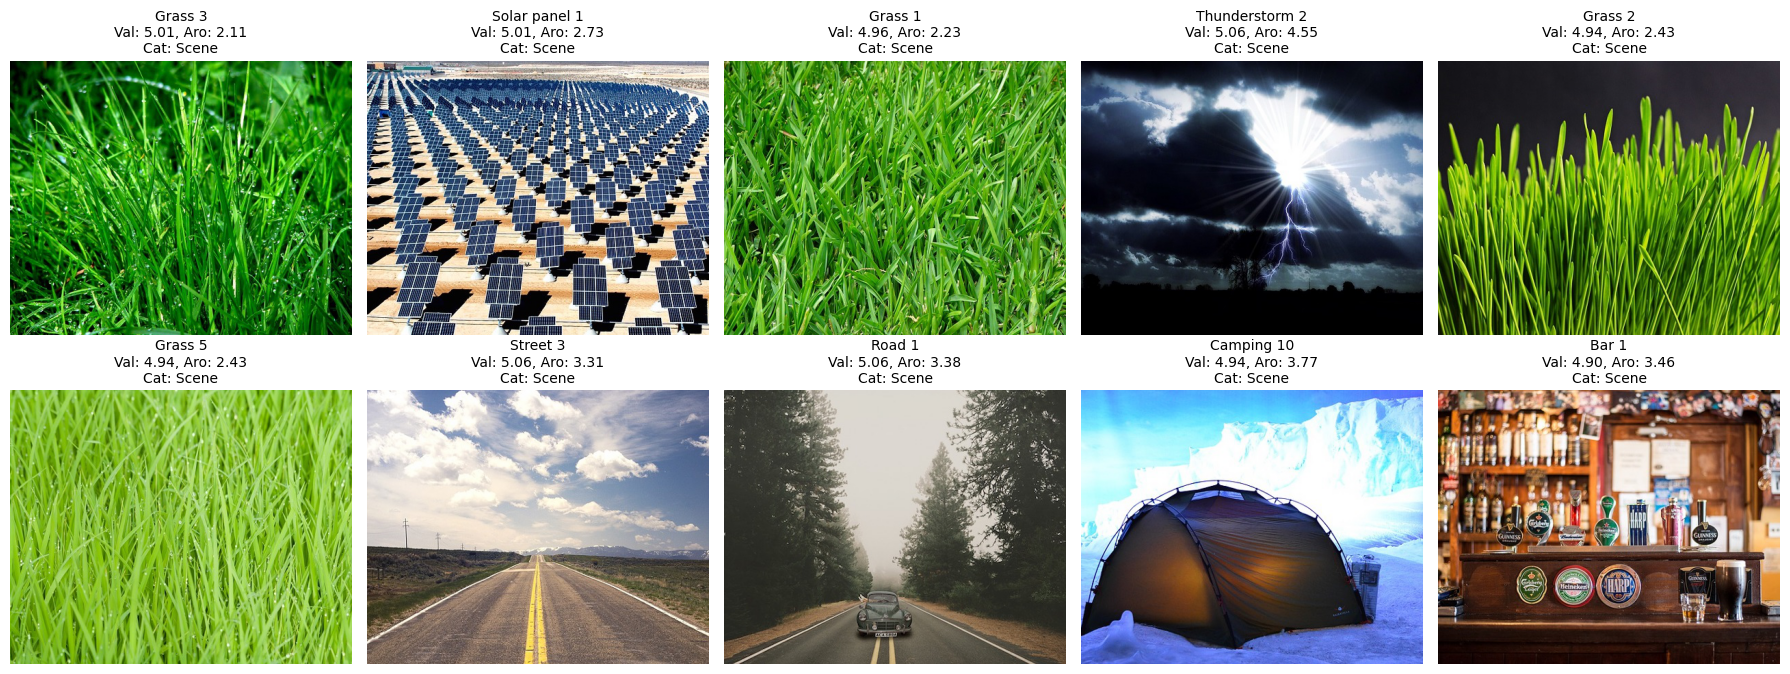

In [26]:
import numpy as np

df_filtered['distance'] = np.sqrt(
    (df_filtered['Valence_mean'] - 5)**2
)

df_filtered = df_filtered[~df_filtered['Theme'].str.startswith('Building')]

top_subset = df_filtered.nsmallest(10, ['distance', 'Arousal_mean']) 

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.ravel()

os.makedirs('neutral', exist_ok=True)

for i, (_, row) in enumerate(top_subset.head(15).iterrows()):
    theme = row['Theme']
    category = row['Category']
    valence = row['Valence_mean']
    arousal = row['Arousal_mean']

    for ext in ['.jpg', '.png', '.jpeg']:
        path = os.path.join(oasis_path, theme + ext)
        if os.path.exists(path):
            img_path = path
            break
    else:
        continue  

    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(
        f"{theme}\nVal: {valence:.2f}, Aro: {arousal:.2f}\nCat: {category}",
        fontsize=10
    )

    filename = os.path.basename(img_path)
    shutil.copy(img_path, os.path.join("neutral", filename))

plt.tight_layout()
plt.show()